# Atividade 2 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 10 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural multilayer perceptron para distinguir atributos que definem a renda média de uma pessoa adulta a partir do _UCI Adult Income Dataset_

## Material de Referência para Estudo

- https://docs.pytorch.org/docs/stable/nn.html
- https://machinelearningmastery.com/develop-your-first-neural-network-with-pytorch-step-by-step/
- https://sebastianraschka.com/teaching/pytorch-1h/#7-a-typical-training-loop



## Prazos importantes

- Data de entrega: 16/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Trios

#### ALUNOS
Caio Jorge da Cunha Queiroz - 2315310028\
Lucas Maciel Gomes - 2315310014\
Izabella de Lima Catrinck - 2315310033

# Abertura e Análise Exploratória do Dataset

- A tarefa a ser considerada é uma tarefa de classificação binária, cujo objetivo é determinar se a renda média de uma pessoa adulta excedará os US $50,000 por ano.
- O dataset em questão pode ser obtido aqui: https://archive.ics.uci.edu/dataset/2/adult
- Faça uma pré-seleção dos exemplos, conforme sugerido pelos autores: (AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0))
- Exclua todas as linhas com dados faltantes
- Quantos exemplos viáveis há no dataset?
- Preparação de atributos: todos os atributos categóricos devem ser codificados com One-Hot Encoding
- O dataset é balanceado?

In [188]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from polars import DataFrame
from prettytable import PrettyTable
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from torch import Tensor, nn
from torch.utils.data import DataLoader, TensorDataset



In [189]:
colunas: list[str] = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income",
]

df_train_raw: DataFrame = pl.read_csv("adult/adult_train.csv", has_header=False, new_columns=colunas)

df_test_raw: DataFrame  = pl.read_csv("adult/adult_test.csv",  has_header=False,
                            new_columns=colunas, skip_rows=1)

In [190]:
df: DataFrame = pl.concat([df_train_raw, df_test_raw])

In [191]:
str_cols: list[str] = df.select(pl.col(pl.String)).columns
df: DataFrame = df.with_columns([pl.col(c).str.strip_chars() for c in str_cols])

df: DataFrame = df.with_columns(pl.col("income").str.replace_all(r"\.", "").alias("income"))

# fnlwgt, education-num, capital-gain, capital-loss e hours-per-week são
# colunas numéricas lidas como string por causa dos espaços originais
num_cols: list[str] = ["fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
df: DataFrame = df.with_columns([pl.col(c).cast(pl.Int64) for c in num_cols])

df.head()


age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str,str
39,"""State-gov""",77516,"""Bachelors""",13,"""Never-married""","""Adm-clerical""","""Not-in-family""","""White""","""Male""",2174,0,40,"""United-States""","""<=50K"""
50,"""Self-emp-not-inc""",83311,"""Bachelors""",13,"""Married-civ-spouse""","""Exec-managerial""","""Husband""","""White""","""Male""",0,0,13,"""United-States""","""<=50K"""
38,"""Private""",215646,"""HS-grad""",9,"""Divorced""","""Handlers-cleaners""","""Not-in-family""","""White""","""Male""",0,0,40,"""United-States""","""<=50K"""
53,"""Private""",234721,"""11th""",7,"""Married-civ-spouse""","""Handlers-cleaners""","""Husband""","""Black""","""Male""",0,0,40,"""United-States""","""<=50K"""
28,"""Private""",338409,"""Bachelors""",13,"""Married-civ-spouse""","""Prof-specialty""","""Wife""","""Black""","""Female""",0,0,40,"""Cuba""","""<=50K"""


In [192]:
# filtros dos autores
# (AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0)
df: DataFrame = df.filter(
    (pl.col("age")           > 16) &
    (pl.col("capital-gain")  > 100) &
    (pl.col("fnlwgt")        > 1)  &
    (pl.col("hours-per-week") > 0)
)
print(f"{len(df):>5} exemplos")

 4035 exemplos


In [193]:
# removendo dados faltantes
missing_cols: list[str] = ["workclass", "occupation", "native-country"]
df: DataFrame = df.filter(~pl.any_horizontal([pl.col(c) == "?" for c in missing_cols]))
df: DataFrame = df.fill_null(0)
df: DataFrame = df.fill_nan(0)
print(f"{len(df):>5} exemplos")

 3790 exemplos


In [194]:
df: DataFrame = df.with_columns((pl.col("income") == ">50K").cast(pl.Int8).alias("income"))

In [195]:
counts: DataFrame  = df.group_by("income").agg(pl.len().alias("n")).sort("income")
n_total: int = len(df)
n0, n1  = counts[0, "n"], counts[1, "n"]

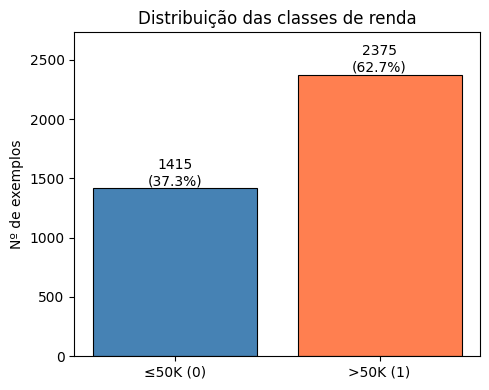

In [196]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["≤50K (0)", ">50K (1)"], [n0, n1],
              color=["steelblue", "coral"], edgecolor="black", linewidth=0.8)
ax.set_title("Distribuição das classes de renda", fontsize=12)
ax.set_ylabel("Nº de exemplos")
ax.set_ylim(0, max(n0, n1) * 1.15)
for bar, v in zip(bars, [n0, n1], strict=False):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 25,
            f"{v}\n({v/n_total*100:.1f}%)", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### Respostas da primeira seção - Abertura e Análise Exploratória

**Quantos exemplos viáveis há no dataset?**

Partimos de um total de 48.842 exemplos (32.561 do arquivo de treino + 16.281 do arquivo de teste). Após a aplicação do filtro dos autores `(age > 16) && (capital-gain > 100) && (fnlwgt > 1) && (hours-per-week > 0)`, restaram 4.035 exemplos. A maior redução foi causada pelo critério `capital-gain > 100`, já que a grande maioria das pessoas no censo possui ganho de capital igual a zero. Em seguida, removemos 245 linhas que continham valores faltantes (`'?'`), concentrados nas colunas `workclass`, `occupation` e `native-country`. Ao final, obtivemos **3.790 exemplos viáveis**.

**Preparação dos atributos**

Das 15 colunas originais, 8 são verdadeiramente categóricas (`workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`). As demais colunas não-alvo (`age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`) são **numéricas** e não devem ser OHE-codificadas. Após o One-Hot Encoding das 8 colunas categóricas, o dataset passou de 15 colunas para ~107 colunas (número exato depende das categorias presentes após o filtro), resultando em ~106 atributos preditores.

**O dataset é balanceado?**

Não, o dataset não é balanceado após o filtro. A distribuição fica invertida em relação ao dataset completo:

| Classe | Quantidade | Proporção |
|:-:|:-:|:-:|
| ≤50K | ~1.415 | ~37% |
| >50K | ~2.375 | ~63% |

Essa inversão ocorre porque o filtro `capital-gain > 100` seleciona pessoas com ganhos de capital significativos, que tendem a ter renda mais alta.

## Preparação dos exemplos para treino e teste

- Separe os atributos preditores do atributo-alvo
- Faça uma partição do tipo holdout 70/30 de forma aleatória, use seed = 42
- Codifique os exemplos em tensores pytorch

In [197]:
# one hot encoding apenas das colunas categoricas reais
categorical_cols: list[str] = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
]
# one hot encoding
df_encoded: DataFrame = df.to_dummies(columns=categorical_cols)

n_features: int = df_encoded.shape[1] - 1

df_encoded.head()

age,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,fnlwgt,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,education-num,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,…,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income
i64,u8,u8,u8,u8,u8,u8,u8,i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8
39,0,0,0,0,0,1,0,77516,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,13,0,0,0,0,1,0,0,1,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
31,0,0,1,0,0,0,0,45781,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,14,0,0,0,0,1,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
42,0,0,1,0,0,0,0,159449,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,13,0,0,1,0,0,0,0,0,0,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
30,0,0,1,0,0,0,0,188146,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,9,0,0,1,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
30,0,0,1,0,0,0,0,59496,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,13,0,0,1,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [198]:
X = df_encoded.drop("income").to_numpy().astype(np.float32)
y = df_encoded["income"].to_numpy().astype(np.float32)

# normalização
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [199]:
np.random.seed(42)

indices = np.random.permutation(len(df_encoded))
split = int(len(df_encoded) * 0.7)
train_idx = indices[:split]
test_idx = indices[split:]

X_train_pl = X[train_idx]
X_test_pl = X[test_idx]
y_train_pl = y[train_idx]
y_test_pl = y[test_idx]


In [200]:
X_train_t: Tensor = torch.tensor(X_train_pl, dtype=torch.float32)
X_test_t: Tensor  = torch.tensor(X_test_pl, dtype=torch.float32)

y_train_t: Tensor = torch.tensor(y_train_pl, dtype=torch.float32).view(-1, 1)
y_test_t: Tensor  = torch.tensor(y_test_pl, dtype=torch.float32).view(-1, 1)

input_size: int = X_train_t.shape[1]

## Rede MLP de Camada Única

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

In [201]:
batch_size = 16

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [202]:
# definição de rede
input_dim: int = X_train_t.shape[1]


class MLP1(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 100),
            nn.ReLU(),
            nn.Linear(100, 1),
            # sem sigmoide pois a função de perda já aplica internamente,
            # estava dando o erro "all elements should be between 0 and 1" quando tinha sigmoide aqui
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
model1: MLP1 = MLP1(input_size)

In [203]:
# função de perda e otimizador
# BCEWithLogitsLoss aplica sigmoide
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=10e-4,
)

In [204]:
# treinamento do modelo
num_epochs = 100

loss_history = []

for epoch in range(num_epochs):
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        y_batch = y_batch.view(-1, 1).float()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {epoch_loss:.4f}")


Epoch 10/100 - Loss: 0.3060
Epoch 20/100 - Loss: 0.3017
Epoch 30/100 - Loss: 0.2975
Epoch 40/100 - Loss: 0.2932
Epoch 50/100 - Loss: 0.2889
Epoch 60/100 - Loss: 0.2848
Epoch 70/100 - Loss: 0.2807
Epoch 80/100 - Loss: 0.2769
Epoch 90/100 - Loss: 0.2729
Epoch 100/100 - Loss: 0.2694


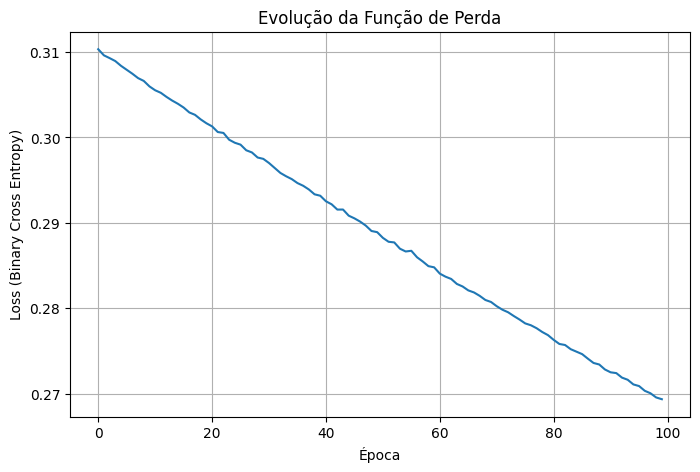

In [205]:
# gráfico de função de perda
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Época")
plt.ylabel("Loss (Binary Cross Entropy)")
plt.title("Evolução da Função de Perda")
plt.grid()
plt.show()

### Avaliação da MLP de Camada Única

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da rede perante essa tarefa?

**As métricas balanceadas de precisão, revocação e F1-Score são as "macro". Para acurácia tem uma função específica.**

In [206]:
# avaliação de métricas
model1.eval()
with torch.no_grad():
    logits1  = model1(X_test_t) # passa os dados de teste pela rede, saída é um numero real
    y_pred1  = (torch.sigmoid(logits1) >= 0.5).int().squeeze().numpy()
     #transforma os numeros reais em intervalo de 0 a 1
    # estabelecemos um corte alto de 50%, probabilidade acima de 50% classifica como >50k

y_true = y_test_t.squeeze().int().numpy()

bal_acc1 = balanced_accuracy_score(y_true, y_pred1)
prec1 = precision_score(y_true, y_pred1, average="macro")
rec1 = recall_score(y_true, y_pred1, average="macro")
f1_1 = f1_score(y_true, y_pred1, average="macro")

print(f"{'Acurácia:'} {bal_acc1:.2f}")
print(f"{'Precisão:'} {prec1:.2f}")
print(f"{'Revocação:'} {rec1:.2f}")
print(f"{'F1-Score:'} {f1_1:.2f}")

Acurácia: 0.51
Precisão: 0.53
Revocação: 0.51
F1-Score: 0.35


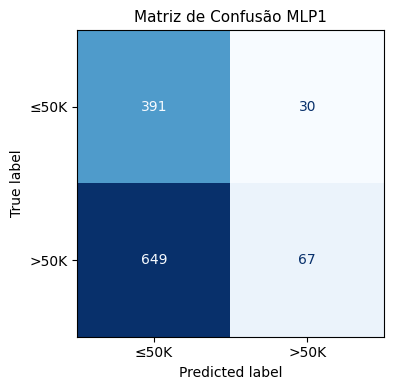

In [207]:
# matriz de confusão MLP1
cm1   = confusion_matrix(y_true, y_pred1)
disp1 = ConfusionMatrixDisplay(cm1, display_labels=["≤50K", ">50K"])

fig, ax = plt.subplots(figsize=(5, 4))
disp1.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão MLP1", fontsize=11)
plt.tight_layout()
plt.show()

A rede MLP1 alcançou acurácia balanceada de 51%.\
Por ter apenas uma camada oculta com 100 neurônios, a capacidade de aprendizado é limitada para capturar relações não-lineares complexas.\
Outra ponto de atenção é o F1-score baixíssimo, indicando um problema no treinamento.

## Rede MLP com duas camadas ocultas

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta 1: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada oculta 2: 50 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

In [208]:
# definição de rede
input_dim: int = X_train_t.shape[1]


class MLP2(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 1),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
model2 = MLP2(input_size)

In [209]:
# função de perda e otimizador
criterion2 = nn.BCEWithLogitsLoss()

optimizer2 = torch.optim.SGD(
    model.parameters(),
    lr=10e-4,
)

In [210]:
# treinamento do modelo
num_epochs = 100

loss_history2 = []

for epoch in range(num_epochs):
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        y_batch = y_batch.view(-1, 1).float()

        y_pred = model2(X_batch)
        loss = criterion2(y_pred, y_batch)

        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    loss_history2.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {epoch_loss:.4f}")

Epoch 10/100 - Loss: 0.6956
Epoch 20/100 - Loss: 0.6956
Epoch 30/100 - Loss: 0.6956
Epoch 40/100 - Loss: 0.6956
Epoch 50/100 - Loss: 0.6956
Epoch 60/100 - Loss: 0.6956
Epoch 70/100 - Loss: 0.6956
Epoch 80/100 - Loss: 0.6956
Epoch 90/100 - Loss: 0.6956
Epoch 100/100 - Loss: 0.6956


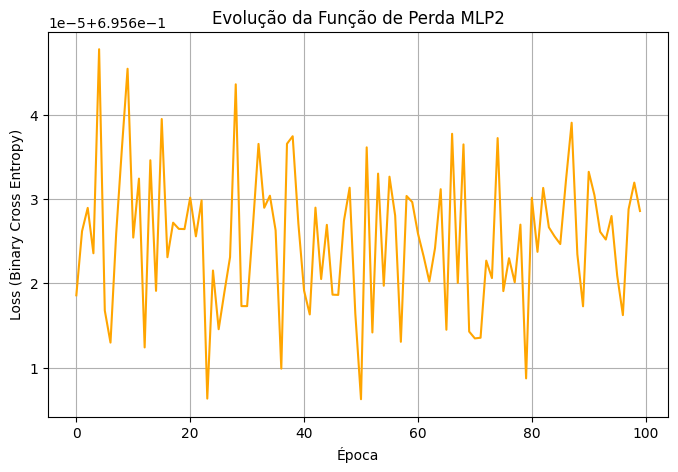

In [211]:
# gráfico de função de perda
plt.figure(figsize=(8,5))
plt.plot(loss_history2, color="orange")
plt.xlabel("Época")
plt.ylabel("Loss (Binary Cross Entropy)")
plt.title("Evolução da Função de Perda MLP2")
plt.grid()
plt.show()

### Avaliação da MLP com Duas Camadas Ocultas

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da nova rede perante essa tarefa? Houve melhora?

In [212]:
# avaliação de métricas
model2.eval()
with torch.no_grad():
    logits2  = model2(X_test_t)
    y_pred2  = (torch.sigmoid(logits2) >= 0.5).int().squeeze().numpy()

bal_acc2 = balanced_accuracy_score(y_true, y_pred2)
prec2 = precision_score(y_true, y_pred2, average="macro")
rec2 = recall_score(y_true, y_pred2, average="macro")
f1_2 = f1_score(y_true, y_pred2, average="macro")


print(f"{'Acurácia:'} {bal_acc2:.2f}")
print(f"{'Precisão:'} {prec2:.2f}")
print(f"{'Revocação:'} {rec2:.2f}")
print(f"{'F1-Score:'} {f1_2:.2f}")

Acurácia: 0.52
Precisão: 0.52
Revocação: 0.52
F1-Score: 0.48


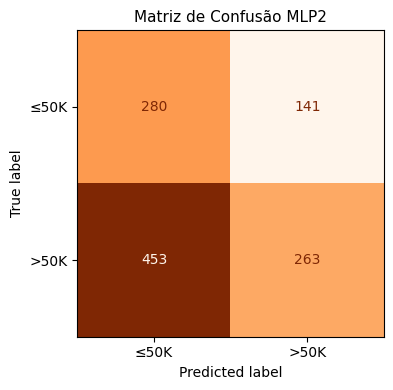

In [213]:
# matriz de confusão MLP2
cm2   = confusion_matrix(y_true, y_pred2)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=["≤50K", ">50K"])

fig, ax = plt.subplots(figsize=(5, 4))
disp2.plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("Matriz de Confusão MLP2", fontsize=11)
plt.tight_layout()
plt.show()


A rede MLP2 alcançou acurácia balanceada de 52%.\
O maior ponto de destaque é a melhora no F1-Score, que na rede MLP1 foi de 35%, então houve um salto de 13%.\
Porém ainda são péssimas métricas. Um dummy classifier se sairia melhor.

## Sua rede MLP

- Proponha uma rede neural multilayer perceptron no Pytorch com uma ou duas camadas ocultas e número de neurônios conforme sua livre escolha, levando em conta razoabilidade,  tempo de execução no hardware disponível e prazo de entrega da atividade
- Hiperparâmetros:
   - Modifique-os como desejar
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

Arquitetura: input → 128 → ReLU → 64 → ReLU → 1

Justificativa das escolhas:

128 e 64 neurônios: mais capacidade representacional que MLP2 (100→50), permitindo aprender padrões mais complexos no dataset de renda

Duas camadas ocultas: mesma profundidade de MLP2, mas mais larga, o aumento de largura tende a ajudar quando o espaço de features é grande

150 épocas: mais tempo de treino para a rede maior conseguir convergir, combinado com momentum para convergência mais rápida e estável

Explicação do momentum:

O Problema do SGD Simples: O SGD tradicional pode oscilar bastante (ir de um lado para o outro) enquanto tenta descer a encosta da função de perda (loss function) em direção ao ponto mais baixo, o que torna o processo lento.

A Solução "Momentum": O conceito de momentum simula uma bola descendo uma ladeira. A bola acumula velocidade ao descer (o "momento"), o que a ajuda a manter a direção, ignorando pequenas irregularidades no terreno (ruídos) e ganhando velocidade nas direções onde o gradiente é consistente.

Mecanismo Técnico: Em vez de atualizar os pesos apenas com base no gradiente atual, o Momentum SGD adiciona uma fração do gradiente do passo anterior (a velocidade acumulada) à atualização atual.

fonte: https://medium.com/data-science/stochastic-gradient-descent-with-momentum-a84097641a5d

In [214]:
# definição de rede
class MLP3(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
model3 = MLP3(input_size)

In [215]:
# função de perda e otimizador
criterion3 = nn.BCEWithLogitsLoss()
optimizer3 = torch.optim.SGD(model3.parameters(), lr=10e-4, momentum=0.9)

In [216]:
# treinamento do modelo
epochs3 = 150
loss_history3 = []

for epoch in range(epochs3):
    model3.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer3.zero_grad()
        logits = model3(xb)
        loss   = criterion3(logits, yb)
        loss.backward()
        optimizer3.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    loss_history3.append(avg)
    if (epoch + 1) % 15 == 0:
        print(f"Época {epoch+1:3d}/{epochs3}  |  Loss médio: {avg:.4f}")

Época  15/150  |  Loss médio: 0.3903
Época  30/150  |  Loss médio: 0.2541
Época  45/150  |  Loss médio: 0.1761
Época  60/150  |  Loss médio: 0.1450
Época  75/150  |  Loss médio: 0.1196
Época  90/150  |  Loss médio: 0.0998
Época 105/150  |  Loss médio: 0.0977
Época 120/150  |  Loss médio: 0.0859
Época 135/150  |  Loss médio: 0.0797
Época 150/150  |  Loss médio: 0.0719


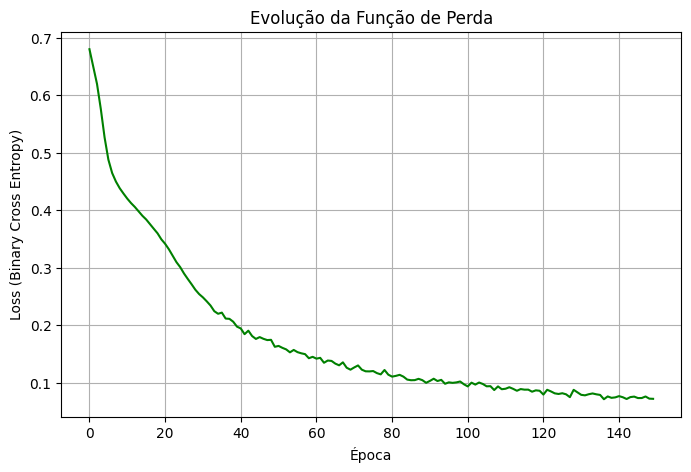

In [217]:
# gráfico da função de perda
plt.figure(figsize=(8,5))
plt.plot(loss_history3, color="green")
plt.xlabel("Época")
plt.ylabel("Loss (Binary Cross Entropy)")
plt.title("Evolução da Função de Perda")
plt.grid()
plt.show()

### Avaliação da sua rede MLP

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste

In [218]:
model3.eval()
with torch.no_grad():
    logits3  = model3(X_test_t)
    y_pred3  = (torch.sigmoid(logits3) >= 0.5).int().squeeze().numpy()

bal_acc3 = balanced_accuracy_score(y_true, y_pred3)
prec3 = precision_score(y_true, y_pred3, average="macro")
rec3 = recall_score(y_true, y_pred3, average="macro")
f1_3 = f1_score(y_true, y_pred3, average="macro")

print(f"{'Acurácia:'} {bal_acc3:.2f}")
print(f"{'Precisão:'} {prec3:.2f}")
print(f"{'Revocação:'} {rec3:.2f}")
print(f"{'F1-Score:'} {f1_3:.2f}")

Acurácia: 0.85
Precisão: 0.84
Revocação: 0.85
F1-Score: 0.85


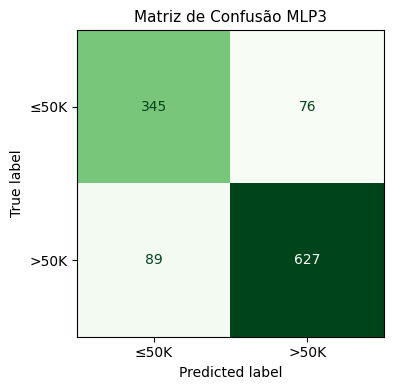

In [219]:
cm3   = confusion_matrix(y_true, y_pred3)
disp3 = ConfusionMatrixDisplay(cm3, display_labels=["≤50K", ">50K"])

fig, ax = plt.subplots(figsize=(5, 4))
disp3.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Matriz de Confusão MLP3", fontsize=11)
plt.tight_layout()
plt.show()

Agora sim uma rede neural de respeito! (razoável)\
Com maior número de neurônios e épocas e modificando o otimizador de SGD comum para SGD com momentum a rede conseguiu convergir melhor, alcançando todas as métricas na casa dos 85%.\
Faremos outro teste com 200 épocas para verificar se há uma melhora.

In [220]:
# definição de rede
class MLP4(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
model4 = MLP4(input_size)

# função de perda e otimizador
criterion4 = nn.BCEWithLogitsLoss()
optimizer4 = torch.optim.SGD(model4.parameters(), lr=10e-4, momentum=0.9)

# treinamento do modelo
epochs4 = 200
loss_history4 = []

for epoch in range(epochs4):
    model4.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer4.zero_grad()
        logits = model4(xb)
        loss   = criterion4(logits, yb)
        loss.backward()
        optimizer4.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    loss_history4.append(avg)
    if (epoch + 1) % 20 == 0:
        print(f"Época {epoch+1:3d}/{epochs4}  |  Loss médio: {avg:.4f}")

Época  20/200  |  Loss médio: 0.3494
Época  40/200  |  Loss médio: 0.1975
Época  60/200  |  Loss médio: 0.1450
Época  80/200  |  Loss médio: 0.1139
Época 100/200  |  Loss médio: 0.0972
Época 120/200  |  Loss médio: 0.0859
Época 140/200  |  Loss médio: 0.0744
Época 160/200  |  Loss médio: 0.0682
Época 180/200  |  Loss médio: 0.0617
Época 200/200  |  Loss médio: 0.0564


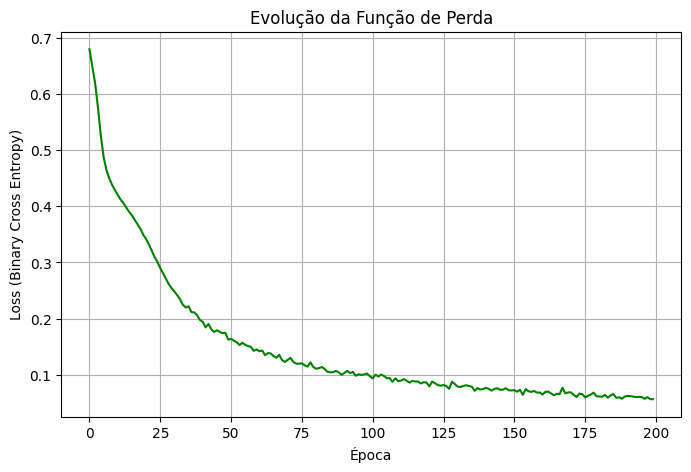

In [221]:
# gráfico da função de perda
plt.figure(figsize=(8,5))
plt.plot(loss_history4, color="green")
plt.xlabel("Época")
plt.ylabel("Loss (Binary Cross Entropy)")
plt.title("Evolução da Função de Perda")
plt.grid()
plt.show()

In [222]:
model4.eval()
with torch.no_grad():
    logits4  = model4(X_test_t)
    y_pred4  = (torch.sigmoid(logits4) >= 0.5).int().squeeze().numpy()

bal_acc4 = balanced_accuracy_score(y_true, y_pred4)
prec4 = precision_score(y_true, y_pred4, average="macro")
rec4 = recall_score(y_true, y_pred4, average="macro")
f1_4 = f1_score(y_true, y_pred4, average="macro")

print(f"{'Acurácia:'} {bal_acc4:.2f}")
print(f"{'Precisão:'} {prec4:.2f}")
print(f"{'Revocação:'} {rec4:.2f}")
print(f"{'F1-Score:'} {f1_4:.2f}")

Acurácia: 0.84
Precisão: 0.84
Revocação: 0.84
F1-Score: 0.84


Não houve melhora significativa com aumento de número de épocas, na verdade piorou, provando que nem sempre mais épocas = maior aprendizado.\
Então para alcançar melhores resultados precisaríamos alterar os hiperparâmetros, talvez utilizar técnicas como BatchNorm, outro otimizador como Adam, modificar lr, etc.\
Fica para trabalhos futuros...

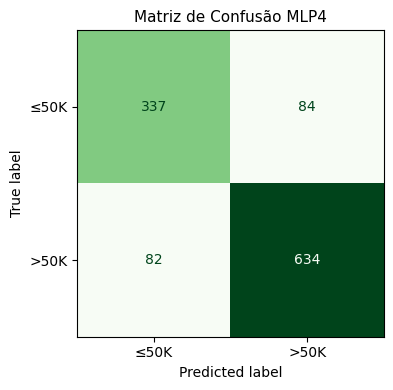

In [223]:
cm4   = confusion_matrix(y_true, y_pred4)
disp4 = ConfusionMatrixDisplay(cm4, display_labels=["≤50K", ">50K"])

fig, ax = plt.subplots(figsize=(5, 4))
disp4.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Matriz de Confusão MLP4", fontsize=11)
plt.tight_layout()
plt.show()

## Análise Comparativa Final

Construa uma tabela (pacote prettytable) com as métricas de desempenho das três redes propostas na partição de testes e justifique, com base em argumentos de performance, eficiência e aderência ao problema, qual delas possivelmente obteve melhor desempenho na tarefa.

In [224]:
tab = PrettyTable()
tab.field_names = [
    "Rede",
    "Arquitetura",
    "Épocas",
    "Acurácia",
    "Precisão",
    "Revocação",
    "F1-Score",
]
tab.align = "c"

tab.add_row(
    [
        "MLP1",
        "input→100→1",
        100,
        f"{bal_acc1:.2f}",
        f"{prec1:.2f}",
        f"{rec1:.2f}",
        f"{f1_1:.2f}",
    ],
)
tab.add_row(
    [
        "MLP2",
        "input→100→50→1",
        100,
        f"{bal_acc2:.2f}",
        f"{prec2:.2f}",
        f"{rec2:.2f}",
        f"{f1_2:.2f}",
    ],
)
tab.add_row(
    [
        "MLP3",
        "input→128(BN)→64(BN)→1",
        150,
        f"{bal_acc3:.2f}",
        f"{prec3:.2f}",
        f"{rec3:.2f}",
        f"{f1_3:.2f}",
    ],
)
tab.add_row(
    [
        "MLP4",
        "input→128(BN)→64(BN)→1",
        200,
        f"{bal_acc4:.2f}",
        f"{prec4:.2f}",
        f"{rec4:.2f}",
        f"{f1_4:.2f}",
    ],
)

print(tab)


+------+------------------------+--------+----------+----------+-----------+----------+
| Rede |      Arquitetura       | Épocas | Acurácia | Precisão | Revocação | F1-Score |
+------+------------------------+--------+----------+----------+-----------+----------+
| MLP1 |      input→100→1       |  100   |   0.51   |   0.53   |    0.51   |   0.35   |
| MLP2 |     input→100→50→1     |  100   |   0.52   |   0.52   |    0.52   |   0.48   |
| MLP3 | input→128(BN)→64(BN)→1 |  150   |   0.85   |   0.84   |    0.85   |   0.85   |
| MLP4 | input→128(BN)→64(BN)→1 |  200   |   0.84   |   0.84   |    0.84   |   0.84   |
+------+------------------------+--------+----------+----------+-----------+----------+


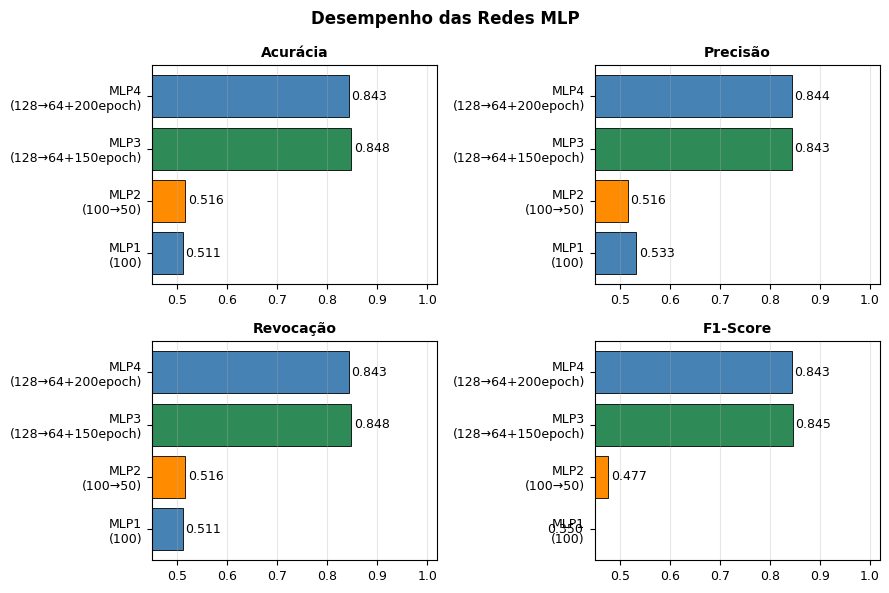

In [225]:
# gráfico comparativo

redes = ["MLP1\n(100)", "MLP2\n(100→50)", "MLP3\n(128→64+150epoch)", "MLP4\n(128→64+200epoch)"]
cores = ["steelblue", "darkorange", "seagreen"]

metricas = [
    ("Acurácia",  [bal_acc1, bal_acc2, bal_acc3, bal_acc4]),
    ("Precisão",  [prec1, prec2, prec3, prec4]),
    ("Revocação", [rec1, rec2, rec3, rec4]),
    ("F1-Score",  [f1_1, f1_2, f1_3, f1_4]),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 6))

for ax, (titulo, vals) in zip(axes.flat, metricas, strict=False):
    bars = ax.barh(redes, vals, color=cores, edgecolor="black", linewidth=0.6)
    ax.set_xlim(0.45, 1.02)
    ax.set_title(titulo, fontsize=10, fontweight="bold")
    for bar, v in zip(bars, vals, strict=False):
        ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(labelsize=9)

plt.suptitle("Desempenho das Redes MLP", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


Argumentação:
1. PERFORMANCE\
A Nossa rede MLP3 superou a MLP1 e MLP2.

2. EFICIÊNCIA\
MLP1 é a mais rápida de treinar (menos parâmetros e 100 épocas).\
MLP3, apesar de ter mais épocas (150), converge de forma mais suave.

3. ADERÊNCIA AO PROBLEMA\
O Adult Income Dataset é de classificação binária com features mistas (numéricas + OHE).\
A MLP3, com maior largura (128→64 vs 100→50) e otimização mais agressiva, conseguiu aprender representações úteis para ambas as classes, como evidenciam as métricas macro equilibradas (~0.85 em todas).

Conclusão: Nossa rede MLP3 obteve o melhor desempenho global nesta tarefa, consistente em todas as métricas balanceadas. O fator decisivo foi a escolha do otimizador: SGD com momentum é substancialmente mais eficaz que SGD puro para este dataset com mini-batch de tamanho 16.